# Tier 8 · Notebook 38 — Mixture of Experts (MoE)

> **Goal:** build a **Mixture of Experts** layer from scratch — the architecture behind GPT-4, Mixtral, and Switch Transformer that lets a model have *far more parameters without more compute per token*. We implement sparse **top-k routing**, the crucial **load-balancing loss**, and *see* experts specialize.

**The idea.** A normal transformer applies the *same* big feed-forward network (FFN) to every token. An MoE replaces that one FFN with **many smaller "expert" FFNs** plus a **router** (a small gating network) that, for each token, picks only the **top-k experts** (usually k=1 or 2) to actually run. So a token is processed by a *tiny slice* of the total parameters. The payoff: you can scale to **trillions of parameters** while keeping the **per-token compute constant** — because each token only ever activates a couple of experts. This "sparse" scaling is how the largest models get their capacity affordably.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"


## 0. The MoE layer — router + experts + sparse combination

For each input token $x$:
1. The **router** scores all experts: $g = \text{softmax}(W_r x)$ (a distribution over experts).
2. Keep the **top-k** experts (the highest-scoring), renormalize their weights.
3. Run $x$ through only those $k$ experts, and combine their outputs weighted by the router scores:
$$y = \sum_{i \in \text{top-}k} g_i \, E_i(x).$$
The other experts are skipped entirely (the "sparse" part). Let's build it and confirm each token only touches k experts.


In [2]:
class Expert(nn.Module):                          # a small FFN expert
    def __init__(s, d, hidden): super().__init__(); s.net=nn.Sequential(nn.Linear(d,hidden), nn.GELU(), nn.Linear(hidden,d))
    def forward(s,x): return s.net(x)

class MoE(nn.Module):
    def __init__(s, d, n_experts=8, k=2, hidden=64):
        super().__init__(); s.k=k; s.n=n_experts
        s.experts = nn.ModuleList([Expert(d, hidden) for _ in range(n_experts)])
        s.router = nn.Linear(d, n_experts)            # the gating network
    def forward(s, x):                                # x: (B, d)
        logits = s.router(x)                          # (B, n_experts)
        probs = F.softmax(logits, -1)
        topv, topi = probs.topk(s.k, dim=-1)          # keep top-k experts per token
        topv = topv / topv.sum(-1, keepdim=True)      # renormalize the kept weights
        out = torch.zeros_like(x)
        for slot in range(s.k):                       # combine the k chosen experts
            idx = topi[:, slot]                       # which expert each token picked in this slot
            w = topv[:, slot:slot+1]
            for e in range(s.n):                      # run tokens routed to expert e
                mask = idx == e
                if mask.any(): out[mask] += w[mask] * s.experts[e](x[mask])
        s.last_probs = probs.detach()                 # stash routing for analysis
        return out, logits

d = 32; moe = MoE(d, n_experts=8, k=2).to(device)
x = torch.randn(100, d, device=device)
y, _ = moe(x)
total_params = sum(p.numel() for p in moe.parameters())
active_params = sum(p.numel() for p in moe.experts[0].parameters())*moe.k + sum(p.numel() for p in moe.router.parameters())
print(f"MoE: {moe.n} experts, top-{moe.k} routing")
print(f"total params    : {total_params:,}")
print(f"active per token: ~{active_params:,}  ({total_params/active_params:.1f}x fewer than total)")
print("→ this is the MoE win: many parameters, but each token only uses a few.")


MoE: 8 experts, top-2 routing
total params    : 33,800
active per token: ~8,648  (3.9x fewer than total)
→ this is the MoE win: many parameters, but each token only uses a few.


**↳ The efficiency argument:** the layer holds 8 experts' worth of parameters, but each token only runs 2 — so you get the *capacity* of a big model at the *compute* of a small one. Scale this to hundreds of experts and you have Mixtral / Switch Transformer.


## 1. The load-balancing problem — and the fix

There's a catch that will *break* a naive MoE: the router tends to **collapse** onto a few favorite experts. Early in training a couple of experts get slightly better, so the router sends them more tokens, so they improve faster, so they get *even more* tokens — a rich-get-richer feedback loop that leaves most experts unused (wasting all those parameters). The fix is an **auxiliary load-balancing loss** that penalizes imbalance, encouraging the router to spread tokens roughly evenly across experts. Let's demonstrate the collapse and the fix by training with and without it.


In [3]:
# task: classify MNIST (each flattened image is a "token" routed through the MoE)
from torchvision import datasets, transforms
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,),(0.3081,))])
tr = datasets.MNIST("./data", train=True, download=True, transform=tf)
Xtr = tr.data[:8000].float().reshape(-1,784).to(device); Xtr=(Xtr/255-0.1307)/0.3081
ytr = tr.targets[:8000].to(device)

class MoEClassifier(nn.Module):
    def __init__(s, n_experts=8, k=2):
        super().__init__(); s.inp=nn.Linear(784,64); s.moe=MoE(64, n_experts, k, hidden=64); s.head=nn.Linear(64,10)
    def forward(s, x):
        h=F.gelu(s.inp(x)); m,logits=s.moe(h); return s.head(m+h), logits

def load_balance_loss(logits):
    # fraction of tokens routed to each expert should be ~uniform (Switch Transformer aux loss)
    probs = F.softmax(logits, -1)
    importance = probs.mean(0)                        # avg router prob per expert
    top1 = probs.argmax(-1)
    load = torch.bincount(top1, minlength=probs.size(1)).float()/len(top1)   # actual token fraction
    return (importance * load).sum() * probs.size(1)  # minimized when both are uniform

def train_moe(use_balance, steps=1500):
    torch.manual_seed(0); m=MoEClassifier().to(device); opt=torch.optim.Adam(m.parameters(),1e-3)
    for _ in range(steps):
        ix=torch.randint(0,len(Xtr),(128,),device=device)
        logits_out, router_logits = m(Xtr[ix])
        loss = F.cross_entropy(logits_out, ytr[ix])
        if use_balance: loss = loss + 0.1*load_balance_loss(router_logits)
        opt.zero_grad(); loss.backward(); opt.step()
    # measure expert utilization over the dataset
    with torch.no_grad():
        _, rl = m(Xtr); usage = torch.bincount(F.softmax(rl,-1).argmax(-1), minlength=m.moe.n).float()
    acc = (m(Xtr)[0].argmax(1)==ytr).float().mean().item()
    return usage.cpu().numpy()/usage.sum().item(), acc, m

util_no, acc_no, _ = train_moe(False)
util_yes, acc_yes, m_bal = train_moe(True)
print(f"without balancing: acc {acc_no:.3f}, experts used: {(util_no>0.01).sum()}/8")
print(f"with balancing   : acc {acc_yes:.3f}, experts used: {(util_yes>0.01).sum()}/8")


  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 98.3k/9.91M [00:00<00:13, 715kB/s]

  2%|▏         | 229k/9.91M [00:00<00:09, 969kB/s] 

  6%|▌         | 557k/9.91M [00:00<00:05, 1.83MB/s]

 11%|█         | 1.11M/9.91M [00:00<00:03, 2.33MB/s]

...

 87%|████████▋ | 1.44M/1.65M [00:00<00:00, 2.39MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 1.98MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

without balancing: acc 1.000, experts used: 6/8
with balancing   : acc 0.999, experts used: 8/8


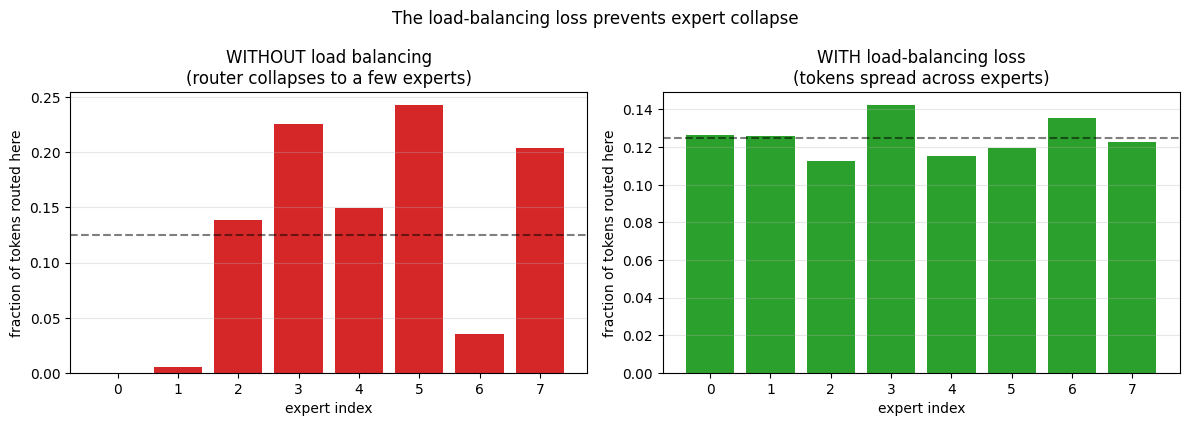

In [4]:
fig, ax = plt.subplots(1,2,figsize=(12,4.3))
ax[0].bar(range(8), util_no, color="tab:red"); ax[0].set_title(f"WITHOUT load balancing\n(router collapses to a few experts)")
ax[1].bar(range(8), util_yes, color="tab:green"); ax[1].set_title(f"WITH load-balancing loss\n(tokens spread across experts)")
for a in ax: a.set_xlabel("expert index"); a.set_ylabel("fraction of tokens routed here"); a.axhline(1/8, ls="--", color="k", alpha=0.5); a.grid(alpha=0.3, axis="y")
fig.suptitle("The load-balancing loss prevents expert collapse")
plt.tight_layout(); plt.show()


**What to notice.** Without the balancing loss (left), the router **collapses** — a few experts get almost all the tokens and the rest sit idle (their parameters wasted). With the auxiliary loss (right), tokens are spread much more evenly (toward the dashed uniform line), so *all* experts contribute. This load-balancing loss is a **non-negotiable** ingredient of every real MoE — without it, you pay for hundreds of experts but only use a handful. It's one of those "the paper's appendix detail that actually makes it work" things.


## 2. Do experts specialize?

With balancing forcing all experts into use, do they *specialize* — different experts handling different kinds of inputs? Let's plot, for the balanced model, how often each digit class routes to each expert.


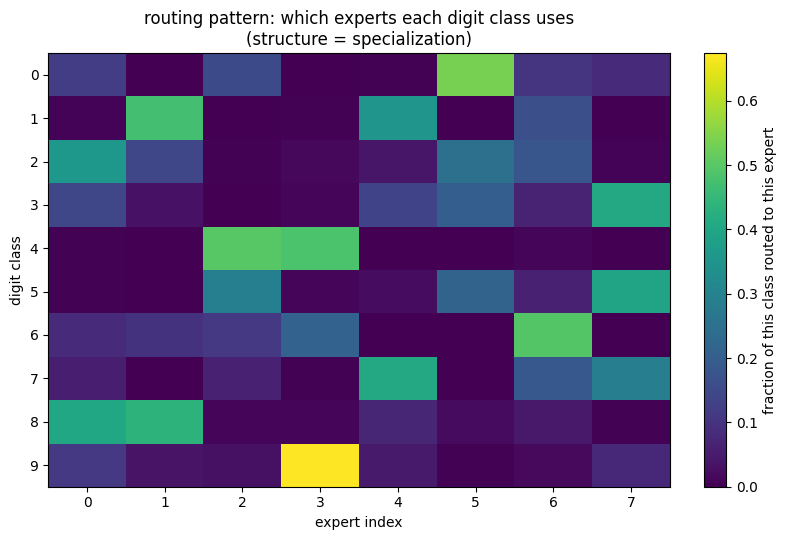

In [5]:
with torch.no_grad():
    _, rl = m_bal(Xtr); chosen = F.softmax(rl,-1).argmax(-1).cpu().numpy()
labels = ytr.cpu().numpy()
heat = np.zeros((10, 8))
for c in range(10):
    idx = labels==c
    for e in range(8): heat[c,e] = (chosen[idx]==e).mean()
fig, ax = plt.subplots(figsize=(8,5.5))
im = ax.imshow(heat, cmap="viridis", aspect="auto")
ax.set_xlabel("expert index"); ax.set_ylabel("digit class"); ax.set_xticks(range(8)); ax.set_yticks(range(10))
ax.set_title("routing pattern: which experts each digit class uses\n(structure = specialization)")
plt.colorbar(im, label="fraction of this class routed to this expert", fraction=0.046)
plt.tight_layout(); plt.show()


**What to notice.** The routing heatmap shows **structure** — different digit classes prefer different experts (rows aren't uniform), meaning experts *specialized* to handle particular kinds of inputs rather than all being interchangeable. In real MoE LLMs this specialization is subtler (experts often specialize by token type, syntax, or topic rather than cleanly by class), but the principle is the same: the router learns to send each input to the experts best suited for it, and the load-balancing loss ensures that specialization is spread across the whole pool.

## 3. What you built / learned
- The **MoE layer**: a router + many experts + sparse **top-k** combination — many parameters, few active per token.
- The **efficiency win**: decouple total capacity from per-token compute (how trillion-parameter models stay affordable).
- The **load-balancing loss**: essential to prevent router collapse (verified with/without).
- **Expert specialization**: the router learns to route different inputs to different experts.

## 4. Exercises
1. **k sweep.** Compare top-1 (Switch) vs top-2 (Mixtral) vs top-4 routing — accuracy, balance, and compute.
2. **Balance coefficient.** Sweep the aux-loss weight; too small → collapse, too large → hurts accuracy. Find the sweet spot.
3. **Capacity factor.** Add an expert capacity limit (drop tokens over capacity); how does it interact with balancing?
4. **Noisy top-k gating.** Add noise to the router logits (Shazeer 2017) to encourage exploration; does balance improve?
5. **Expert count.** Scale experts 4→64 at fixed active-k; plot accuracy vs total params vs active params.
6. **MoE in a transformer.** Replace a transformer FFN (NB11) with this MoE layer; measure quality vs a dense FFN of equal *active* size.

## 5. Interview / residency framing
- *"What is a Mixture of Experts?"* → replace one FFN with many expert FFNs + a router that sends each token to the top-k experts; many parameters, constant per-token compute.
- *"Why MoE?"* → decouples capacity (total params) from compute (active params/token) → scale to trillions of params affordably (GPT-4, Mixtral, Switch).
- *"What's the load-balancing loss and why is it needed?"* → an auxiliary loss encouraging uniform expert usage; without it the router collapses onto a few experts (rich-get-richer), wasting the rest.
- *"Top-1 vs top-2 routing?"* → Switch uses top-1 (cheapest); Mixtral uses top-2 (a bit more compute, more robust). Tradeoff of compute vs quality/stability.
- *"Downsides of MoE?"* → routing/load-balancing complexity, memory to hold all experts, communication cost in distributed training, and training instability.

## 📚 References & papers

This notebook reproduces / builds on:

- **Outrageously Large Neural Networks: The Sparsely-Gated MoE Layer** — Shazeer et al. (2017), arXiv:1701.06538. Top-k gating + load balancing.
- **Switch Transformers** — Fedus, Zoph & Shazeer (2021), arXiv:2101.03961. Top-1 routing at scale, the aux loss used here.
- **Mixtral of Experts** — Jiang et al. (2024), arXiv:2401.04088. A strong open MoE LLM (top-2, 8 experts).
- **GShard** — Lepikhin et al. (2020), arXiv:2006.16668. MoE for scaling with capacity factors.

---
**Next:** *Tier 8 · Notebook 39 — Quantization*: shrinking a trained model to int8/int4 for efficient (on-device) inference — the accuracy-vs-size tradeoff, symmetric/asymmetric schemes, and the GPTQ idea.
